# DriftGuard — Final Evaluation

In this notebook, I consolidate the results from the previous experiments and perform the final evaluation of the DriftGuard classification system.

I will compare the non-adaptive and adaptive models using the same streaming evaluation framework and focus on accuracy, F1-score, recall, and performance across the stream.

The goal is to determine how the models behave under changing data conditions and whether the adaptation strategies provide a practical benefit.

## Objective

I will use the results generated in the previous notebooks to:

1. Compare all four model configurations.
2. Evaluate performance across the streaming batches.
3. Compare adaptive and non-adaptive approaches.
4. Identify the strongest model for each evaluation metric.
5. Summarize the final findings and limitations.

I will use the previously generated results rather than rerunning the complete streaming experiments.

In [1]:
# Import the libraries needed for the final evaluation
import pandas as pd
import matplotlib.pyplot as plt

# Define the project results directory
results_path = r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results"

# Load the non-adaptive Gaussian NB results
nb_results = pd.read_csv(
    results_path + r"\incremental_nb_streaming_results.csv"
)

# Load the non-adaptive KNN results
knn_results = pd.read_csv(
    results_path + r"\windowed_knn_streaming_results.csv"
)

# Load the adaptive Gaussian NB results
adaptive_nb_results = pd.read_csv(
    results_path + r"\adaptive_nb_streaming_results.csv"
)

# Load the adaptive KNN results
adaptive_knn_results = pd.read_csv(
    results_path + r"\adaptive_knn_streaming_results.csv"
)

# Confirm the number of evaluated batches
print("Incremental NB batches:", len(nb_results))
print("Windowed KNN batches:", len(knn_results))
print("Adaptive NB batches:", len(adaptive_nb_results))
print("Adaptive KNN batches:", len(adaptive_knn_results))

Incremental NB batches: 90
Windowed KNN batches: 90
Adaptive NB batches: 90
Adaptive KNN batches: 90


In [2]:
# Create the final performance comparison
final_comparison = pd.DataFrame([
    {
        "model": "Incremental Gaussian NB",
        "accuracy": nb_results["accuracy"].mean(),
        "f1": nb_results["f1"].mean(),
        "recall": nb_results["recall"].mean()
    },
    {
        "model": "Adaptive Gaussian NB",
        "accuracy": adaptive_nb_results["accuracy"].mean(),
        "f1": adaptive_nb_results["f1"].mean(),
        "recall": adaptive_nb_results["recall"].mean()
    },
    {
        "model": "Windowed KNN",
        "accuracy": knn_results["accuracy"].mean(),
        "f1": knn_results["f1"].mean(),
        "recall": knn_results["recall"].mean()
    },
    {
        "model": "Adaptive Windowed KNN",
        "accuracy": adaptive_knn_results["accuracy"].mean(),
        "f1": adaptive_knn_results["f1"].mean(),
        "recall": adaptive_knn_results["recall"].mean()
    }
])

# Round the metrics for easier reading
final_comparison[["accuracy", "f1", "recall"]] = final_comparison[
    ["accuracy", "f1", "recall"]
].round(4)

# Display the final comparison
final_comparison

,model,accuracy,f1,recall
0,Incremental Gaussian NB,0.7143,0.5125,0.4539
1,Adaptive Gaussian NB,0.7162,0.5161,0.4595
2,Windowed KNN,0.6973,0.6139,0.5967
3,Adaptive Windowed KNN,0.6972,0.6140,0.5970


In [3]:
# Save the final model comparison
final_comparison.to_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results\final_model_comparison.csv",
    index=False
)

# Confirm that the result was saved
print("Final model comparison saved successfully.")

Final model comparison saved successfully.


## Final Model Performance

I now visualize the final performance of all four model configurations.

This comparison makes it easier to see the trade-offs between overall accuracy, F1-score, and recall across the streaming models.

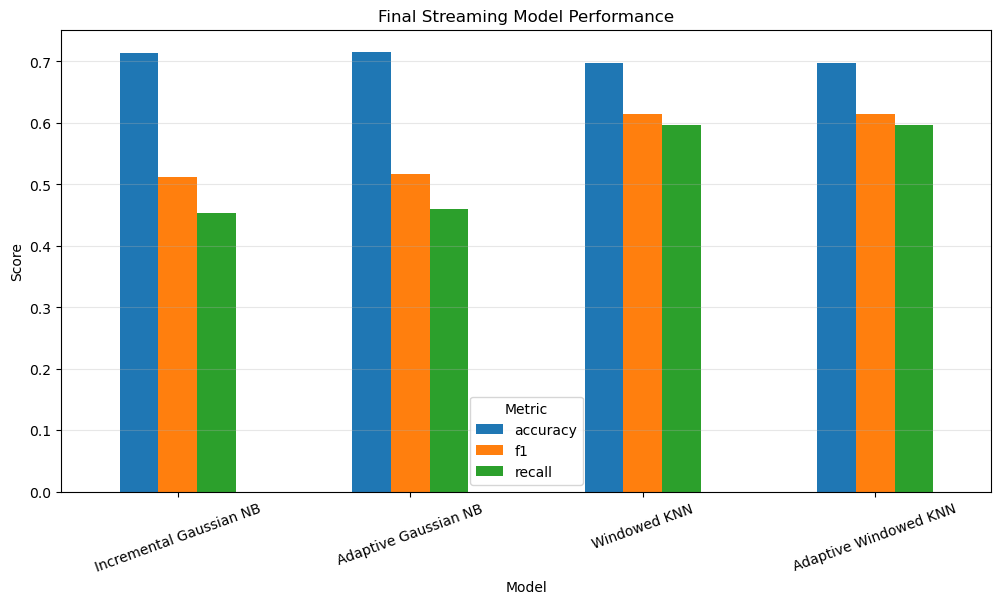

In [4]:
# Create the final performance comparison chart
final_comparison.set_index("model")[["accuracy", "f1", "recall"]].plot(
    kind="bar",
    figsize=(12, 6)
)

# Add labels and title
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Final Streaming Model Performance")

# Keep the chart readable
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

# Save the final figure
plt.savefig(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\figures\final_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

In [5]:
# Compare adaptive models with their non-adaptive counterparts
nb_improvement = {
    "accuracy_change": round(
        final_comparison.loc[1, "accuracy"] -
        final_comparison.loc[0, "accuracy"], 4
    ),
    "f1_change": round(
        final_comparison.loc[1, "f1"] -
        final_comparison.loc[0, "f1"], 4
    ),
    "recall_change": round(
        final_comparison.loc[1, "recall"] -
        final_comparison.loc[0, "recall"], 4
    )
}

knn_improvement = {
    "accuracy_change": round(
        final_comparison.loc[3, "accuracy"] -
        final_comparison.loc[2, "accuracy"], 4
    ),
    "f1_change": round(
        final_comparison.loc[3, "f1"] -
        final_comparison.loc[2, "f1"], 4
    ),
    "recall_change": round(
        final_comparison.loc[3, "recall"] -
        final_comparison.loc[2, "recall"], 4
    )
}

# Display the improvement from adaptation
print("Gaussian NB improvement:", nb_improvement)
print("KNN improvement:", knn_improvement)

Gaussian NB improvement: {'accuracy_change': np.float64(0.0019), 'f1_change': np.float64(0.0036), 'recall_change': np.float64(0.0056)}
KNN improvement: {'accuracy_change': np.float64(-0.0001), 'f1_change': np.float64(0.0001), 'recall_change': np.float64(0.0003)}


## Final Findings

I compared four streaming model configurations using the same sequential evaluation setup.

The results show that Gaussian Naive Bayes achieved the highest accuracy, while Windowed KNN achieved higher F1-score and recall.

Adaptive Gaussian NB improved slightly over the non-adaptive version across accuracy, F1-score, and recall. Adaptive KNN also improved slightly, but the difference was marginal.

This shows that the benefit of adaptation depends on the model and its existing ability to handle recent data. Gaussian NB benefits more from explicitly reducing the influence of older statistics, while KNN already uses a recent observation window.

## Limitations

I consider the following limitations when interpreting the results:

- The dataset does not provide ground-truth drift labels, so Page-Hinkley detections are treated as candidate change points rather than confirmed drift events.
- The Page-Hinkley parameters were selected based on the observed error-signal behavior and were not optimized against a known drift ground truth.
- The KNN window size of 2,000 observations is an experimental baseline rather than a proven optimal value.
- The adaptive strategies produced only modest improvements in this experiment, so the results should not be interpreted as proof that adaptation will always improve performance.
- The final evaluation is based on one streaming benchmark dataset and should be validated on additional non-stationary datasets before making broader claims.

## Conclusion

I built and evaluated DriftGuard as an adaptive classification system for non-stationary streaming data.

The project follows the **Learn → Detect → Adapt** workflow. Incremental Gaussian Naive Bayes and Windowed KNN provide the learning component, Page-Hinkley monitors changes in prediction-error behavior, and the adaptive models respond to detected changes.

The final comparison showed that adaptation produced small improvements for both models. Adaptive Gaussian NB achieved the highest overall accuracy, while Adaptive KNN achieved the highest F1-score and recall.

The results demonstrate the feasibility of combining incremental learning, drift detection, and model adaptation in a single streaming classification workflow. However, the improvements are modest and should be interpreted within the limitations of the dataset and experimental configuration.

This completes the experimental evaluation of DriftGuard.